# DSP Signal Visualization

Loads the newest `debug_<TIMESTAMP>.csv` from the `data/` dir and plots the raw and filtered acceleration magnitudes from the digital signal processing thread when running `tools/debug_stream.py`. 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "data"
OPTIONAL_DATA_FILEPATH = None

## 1. Load data

In [2]:
candidates = sorted(DATA_DIR.glob("debug_*.csv"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError(f"no debug_*.csv under {DATA_DIR}")

csv_path = OPTIONAL_DATA_FILEPATH if OPTIONAL_DATA_FILEPATH else candidates[-1]
print(f"Using: {csv_path.name}")

df = pd.read_csv(csv_path)
df = df.sort_values(by="timestampUs")

# Remove the 0 timestamp row
df = df.iloc[1:]

# Time axis: seconds from first sample (microsecond timestamps from firmware)
t = (df["timestampUs"] - df["timestampUs"].iloc[0]) * 1e-6

df.head()

Using: debug_20260430_153205.csv


,timestampUs,ax,ay,az,mag,slope
1,189699560,0.001987,-0.000065,0.000030,0.002662,-0.000212
2,189709540,0.002282,0.000647,-0.001036,0.002645,-0.000018
3,189718542,0.000318,-0.000319,0.000415,0.002159,-0.000486
4,189728552,-0.001467,-0.001493,-0.001254,0.002226,0.000067
5,189738532,-0.000357,-0.000382,0.002926,0.002405,0.000179


## 2. Time series: accelerations (ax, ay, az)

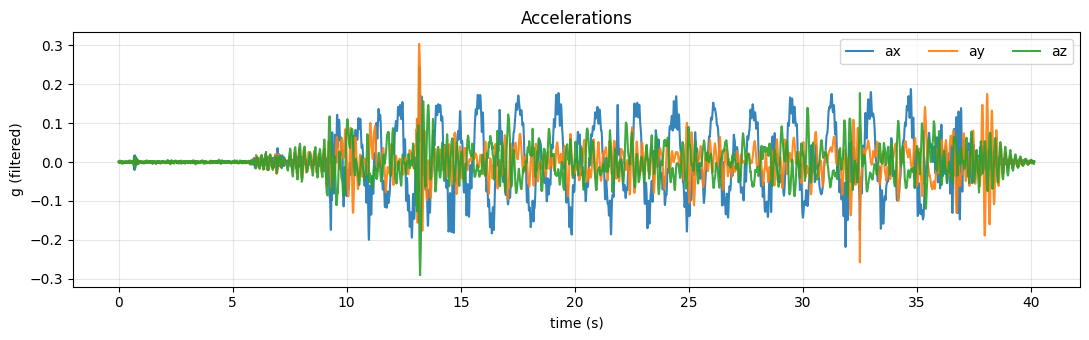

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, df["ax"], label="ax", alpha=0.9)
ax.plot(t, df["ay"], label="ay", alpha=0.9)
ax.plot(t, df["az"], label="az", alpha=0.9)
ax.set_xlabel("time (s)")
ax.set_ylabel("g (filtered)")
ax.set_title("Accelerations")
ax.legend(loc="upper right", ncol=3)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Magnitude and slope

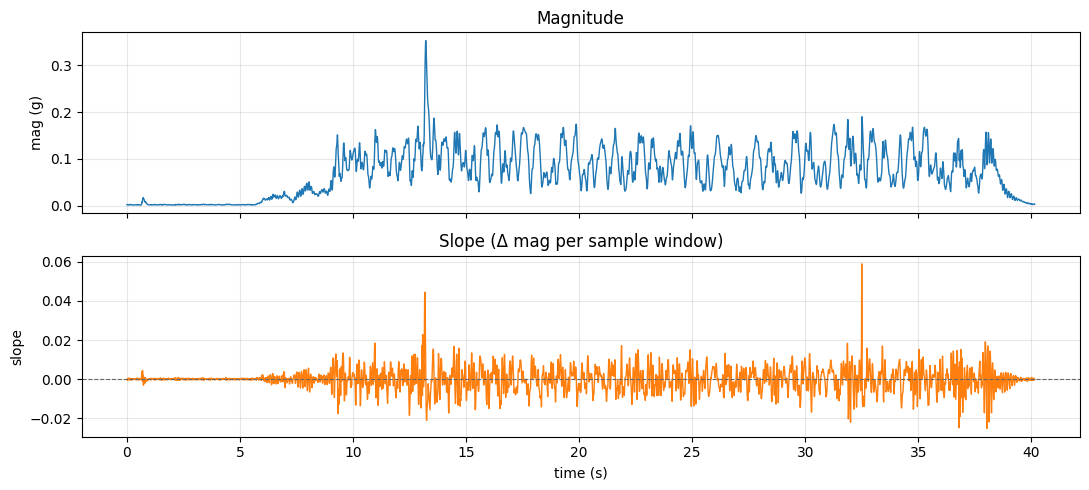

In [4]:
fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a0.plot(t, df["mag"], color="C0", lw=1.0)
a0.set_ylabel("mag (g)")
a0.set_title("Magnitude")
a0.grid(True, alpha=0.3)

a1.plot(t, df["slope"], color="C1", lw=1.0)
a1.set_xlabel("time (s)")
a1.set_ylabel("slope")
a1.set_title("Slope (Δ mag per sample window)")
a1.axhline(0, color="0.4", ls="--", lw=0.8)
a1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Step Detection

Minimal **streaming** peak detector on **mag** (bandpass-filtered magnitude), causal single pass:

1. **EMA baseline** on mag → `x_d = mag - baseline` (`EMA_ALPHA = 0.02`)
2. **Motion hysteresis** on `|x_d|`: enter `in_motion` above `enter_th`, exit below `exit_th` (no variance / z-scores)
3. **Step** = local maximum of `x_d` at `i-1` (`x_d[i-1] > x_d[i-2]` and `x_d[i-1] > x_d[i]`), `x_d[i-1] > PEAK_THRESHOLD`, refractory timer, and `in_motion` was true at `i-1`

`state_seq`: `0` = idle, `1` = motion. On the MCU, set `MAG_SCALE = 1.0` and use the same `enter_th` / `exit_th` / `PEAK_THRESHOLD` when `mag` already matches those excursions.


In [38]:
# --- Tunables (mirror in firmware headers) ---
EMA_ALPHA = 0.02

# Linear scale on mag before EMA (1.0 on MCU). Debug CSV exports here use smaller
# amplitude; ~4.35 aligns excursions with the thresholds below on bundled `debug_*.csv`.
MAG_SCALE = 4.35

enter_th = 0.15  # start motion
exit_th = 0.08  # stop motion

PEAK_THRESHOLD = 0.2
REFRACTORY_S = 0.35


def detect_steps_streaming(df):
    """
    Minimal streaming step detector: EMA detrend + hysteresis motion + local-max peaks.

    Returns
    -------
    step_indices : list[int]
    step_times : list[float]  # seconds from first timestamp
    x_detrended, baseline_arr : np.ndarray
    state_seq : np.ndarray int8  # 0 = idle, 1 = motion
    """
    mag = df["mag"].to_numpy(dtype=np.float64, copy=False)
    ts = df["timestampUs"].to_numpy(dtype=np.float64, copy=False)
    t = (ts - ts[0]) * 1e-6
    n = len(mag)

    if n == 0:
        e = np.array([], dtype=np.float64)
        return [], [], e, e, np.array([], dtype=np.int8)

    x_detrended = np.zeros(n, dtype=np.float64)
    baseline_arr = np.zeros(n, dtype=np.float64)
    state_seq = np.zeros(n, dtype=np.int8)

    step_indices = []
    step_times = []

    baseline = float(mag[0]) * MAG_SCALE
    in_motion = False
    last_step_t = -1.0e30
    a = EMA_ALPHA

    for i in range(n):
        x = float(mag[i]) * MAG_SCALE
        baseline = a * x + (1.0 - a) * baseline
        x_d = x - baseline

        x_detrended[i] = x_d
        baseline_arr[i] = baseline

        if not in_motion:
            if abs(x_d) > enter_th:
                in_motion = True
        else:
            if abs(x_d) < exit_th:
                in_motion = False

        state_seq[i] = 1 if in_motion else 0

        if i >= 2 and state_seq[i - 1] == 1:
            xd_im1 = x_detrended[i - 1]
            xd_i2 = x_detrended[i - 2]
            xd_i = x_d
            local_max = xd_im1 > xd_i2 and xd_im1 > xd_i
            t_peak = float(t[i - 1])
            if (
                local_max
                and xd_im1 > PEAK_THRESHOLD
                and (t_peak - last_step_t) >= REFRACTORY_S
            ):
                step_indices.append(i - 1)
                step_times.append(t_peak)
                last_step_t = t_peak

    return step_indices, step_times, x_detrended, baseline_arr, state_seq



In [39]:
out = detect_steps_streaming(df)
(
    step_indices,
    step_times,
    x_detrended,
    baseline_arr,
    state_seq,
) = out

print(f"Detected steps: {len(step_indices)}")


Detected steps: 30


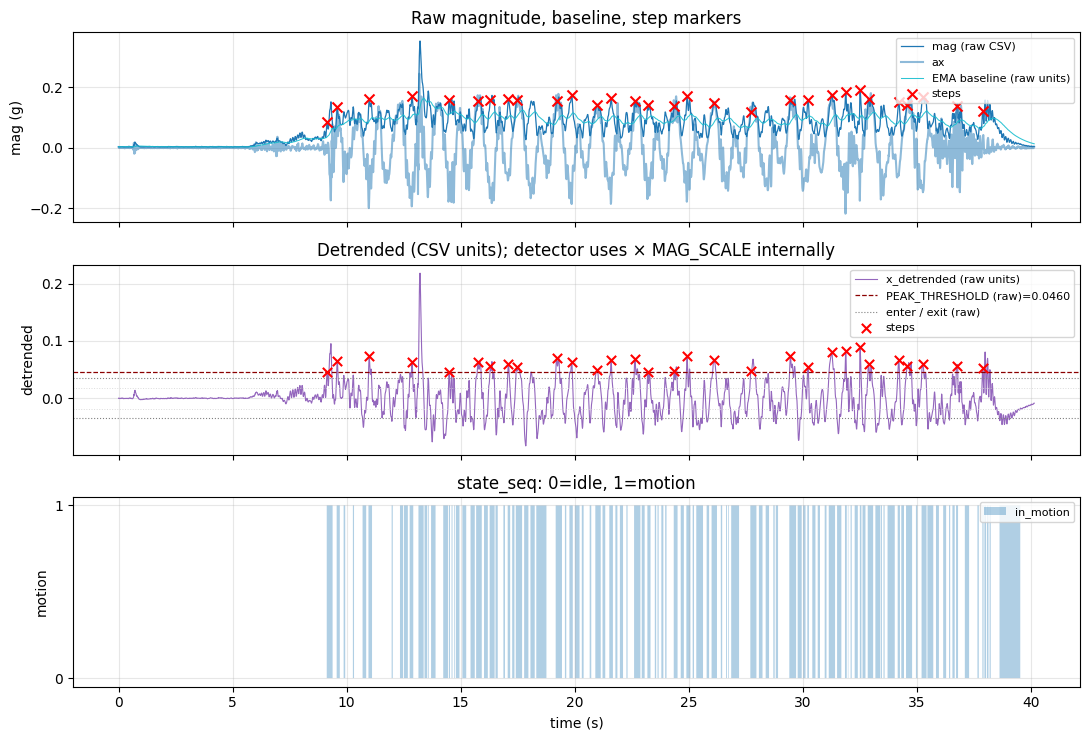

In [41]:
t_np = np.asarray(t, dtype=float)
mag_np = np.asarray(df["mag"], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)

ax0 = axes[0]
ax0.plot(t_np, mag_np, label="mag (raw CSV)", color="tab:blue", lw=0.9)
ax0.plot(t_np, df["ax"], label="ax", alpha=0.5)
ax0.plot(
    t_np,
    baseline_arr / MAG_SCALE,
    label="EMA baseline (raw units)",
    color="tab:cyan",
    lw=0.75,
    alpha=0.9,
)
if len(step_indices):
    ax0.scatter(
        t_np[step_indices],
        mag_np[step_indices],
        color="red",
        s=52,
        marker="x",
        zorder=5,
        label="steps",
    )
ax0.set_ylabel("mag (g)")
ax0.set_title("Raw magnitude, baseline, step markers")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper right", fontsize=8)

ax1 = axes[1]
xd_plot = x_detrended / MAG_SCALE
ax1.plot(t_np, xd_plot, color="tab:purple", lw=0.8, label="x_detrended (raw units)")
ax1.axhline(
    PEAK_THRESHOLD / MAG_SCALE,
    color="darkred",
    ls="--",
    lw=0.9,
    label=f"PEAK_THRESHOLD (raw)={PEAK_THRESHOLD/MAG_SCALE:.4f}",
)
ax1.axhline(enter_th / MAG_SCALE, color="gray", ls=":", lw=0.8, label="enter / exit (raw)")
ax1.axhline(-enter_th / MAG_SCALE, color="gray", ls=":", lw=0.8)
ax1.axhline(exit_th / MAG_SCALE, color="lightgray", ls=":", lw=0.7, alpha=0.8)
ax1.axhline(-exit_th / MAG_SCALE, color="lightgray", ls=":", lw=0.7, alpha=0.8)
if len(step_indices):
    ax1.scatter(
        t_np[step_indices],
        xd_plot[step_indices],
        color="red",
        s=45,
        marker="x",
        zorder=5,
        label="steps",
    )
ax1.set_ylabel("detrended")
ax1.set_title("Detrended (CSV units); detector uses × MAG_SCALE internally")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8)

ax2 = axes[2]
ax2.fill_between(t_np, 0.0, state_seq.astype(float), step="post", alpha=0.35, label="in_motion")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("motion")
ax2.set_title("state_seq: 0=idle, 1=motion")
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()


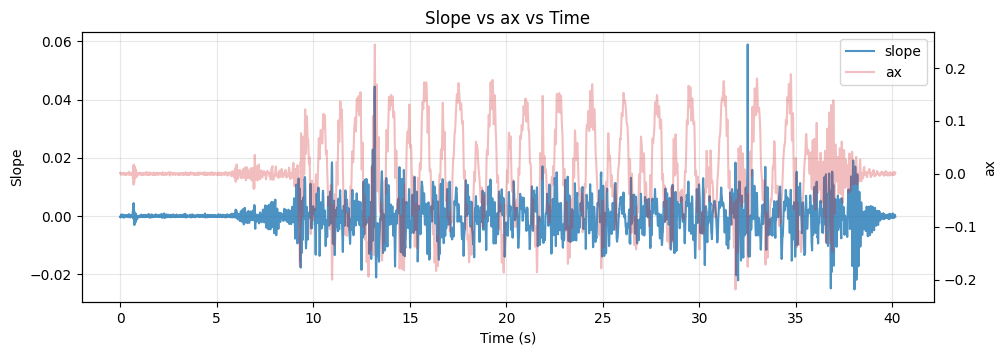

In [20]:
fig, ax1 = plt.subplots(figsize=(11, 3.5))

ax1.plot(t, df["slope"], label="slope", alpha=0.8, color="tab:blue")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Slope")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t, df["ax"], label="ax", alpha=0.3, color="tab:red")
ax2.set_ylabel("ax")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Slope vs ax vs Time")

plt.show()
